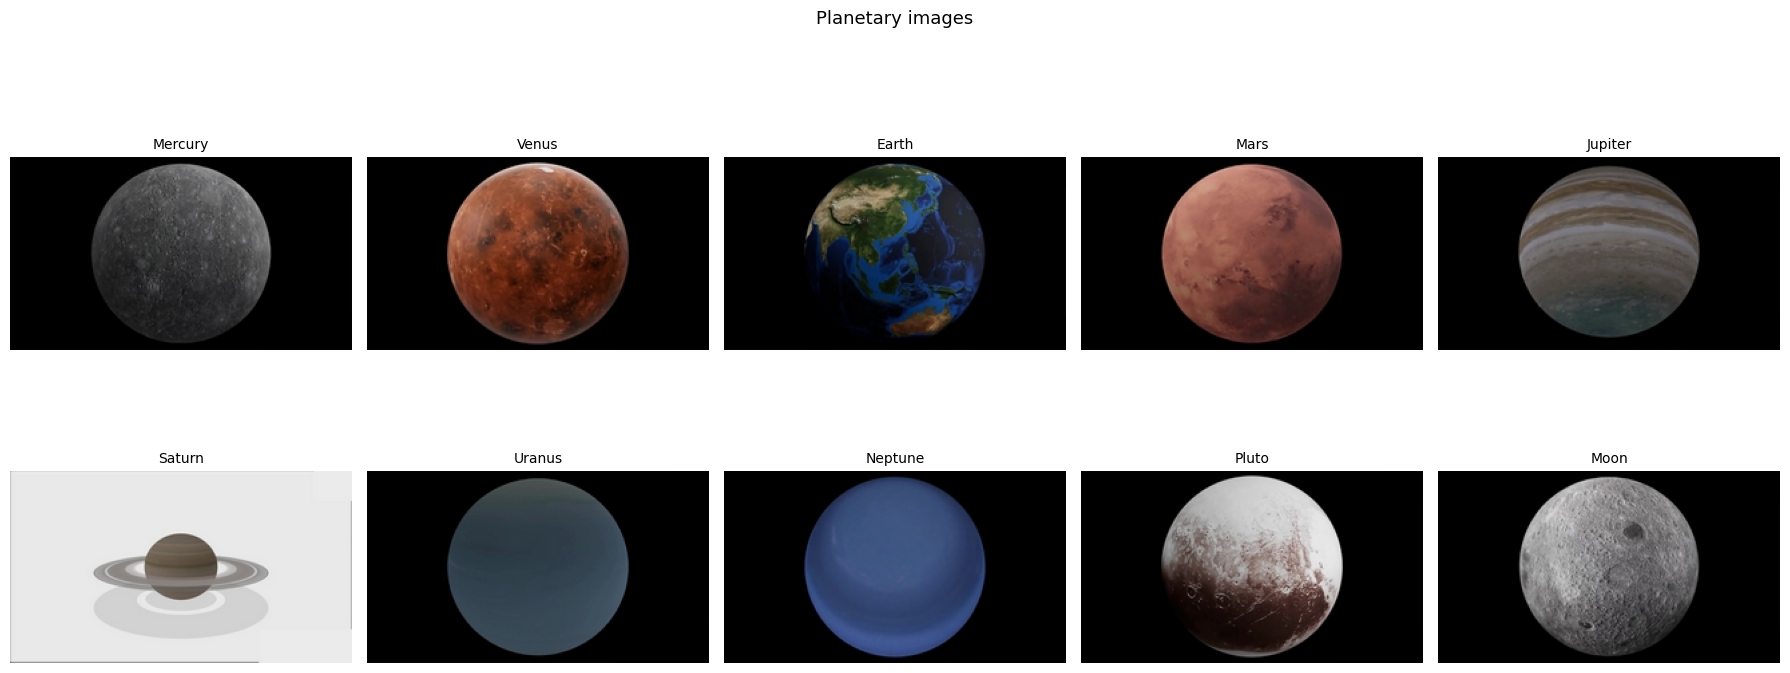

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

base = '../data/planets/Planets_Moons_Data/Planets and Moons'
planets = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 
           'Saturn', 'Uranus', 'Neptune', 'Pluto', 'Moon']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, planet in zip(axes.flat, planets):
    img_dir = os.path.join(base, planet)
    img = Image.open(os.path.join(img_dir, os.listdir(img_dir)[0])).convert('RGB')
    ax.imshow(np.array(img))
    ax.set_title(planet, fontsize=10)
    ax.axis('off')

plt.suptitle('Planetary images', fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
import sys
sys.path.append('../')

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from PIL import Image
from src.models.trainer import train, final_evaluate

PLANET_CLASSES = [
    'Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter',
    'Saturn', 'Uranus', 'Neptune', 'Pluto', 'Moon'
]
BASE_DIR = '../data/planets/Planets_Moons_Data/Planets and Moons'
TARGET_COUNT = 500  # augmented each class to 500 images
BATCH_SIZE = 32
DEVICE = torch.device('mps')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms(split='train'):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.ToTensor(),
])

class PlanetDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


all_images, all_labels = [], []

for class_idx, planet in enumerate(PLANET_CLASSES):
    folder = os.path.join(BASE_DIR, planet)
    originals = []
    for fname in os.listdir(folder):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        try:
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            originals.append(np.array(img, dtype=np.uint8))
        except:
            pass

    n_orig = len(originals)
    for img in originals:
        all_images.append(img)
        all_labels.append(class_idx)

    needed = TARGET_COUNT - n_orig
    for i in range(needed):
        src = Image.fromarray(originals[i % n_orig])
        aug = aug_transform(src)
        aug_np = (aug.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
        all_images.append(aug_np)
        all_labels.append(class_idx)

    print(f"{planet}: {n_orig} → {TARGET_COUNT}")

all_labels = np.array(all_labels)
print(f"\nTotal: {len(all_images)} images, {len(PLANET_CLASSES)} classes")

indices = np.arange(len(all_images))
idx_train, idx_temp = train_test_split(indices, test_size=0.30, random_state=42, stratify=all_labels)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50, random_state=42, stratify=all_labels[idx_temp])

def subset(idx_list):
    return [all_images[i] for i in idx_list], all_labels[idx_list]

X_train, y_train = subset(idx_train)
X_val,   y_val   = subset(idx_val)
X_test,  y_test  = subset(idx_test)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


train_dataset = PlanetDataset(X_train, y_train, get_transforms('train'))
val_dataset   = PlanetDataset(X_val,   y_val,   get_transforms('val'))
test_dataset  = PlanetDataset(X_test,  y_test,  get_transforms('test'))

counts = np.bincount(y_train)
weights = torch.tensor(1.0 / counts[y_train], dtype=torch.float)
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)


def build_planet_model(num_classes=10, freeze_backbone=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )
    return model

print("\n=== Phase 1: training classifier head ===")
model = build_planet_model(num_classes=10, freeze_backbone=True).to(DEVICE)

config_p1 = {
    'epochs': 10, 'lr': 1e-3, 'weight_decay': 1e-4,
    'checkpoint_dir': '../outputs/checkpoints/',
    'run_name': 'planet_phase1', 'use_wandb': False,
}
train(model, train_loader, val_loader, config_p1, DEVICE, PLANET_CLASSES)

print("\n=== Phase 2: fine-tuning full network ===")
model = build_planet_model(num_classes=10, freeze_backbone=False).to(DEVICE)
model.load_state_dict(torch.load('../outputs/checkpoints/planet_phase1_best.pth', map_location=DEVICE))

config_p2 = {
    'epochs': 15, 'lr': 1e-4, 'weight_decay': 1e-4,
    'checkpoint_dir': '../outputs/checkpoints/',
    'run_name': 'planet_phase2', 'use_wandb': False,
}
train(model, train_loader, val_loader, config_p2, DEVICE, PLANET_CLASSES)

print("\n=== Final evaluation ===")
model.load_state_dict(torch.load('../outputs/checkpoints/planet_phase2_best.pth', map_location=DEVICE))
cm = final_evaluate(model, test_loader, DEVICE, PLANET_CLASSES)
print(cm)

Mercury: 149 → 500
Venus: 149 → 500
Earth: 149 → 500
Mars: 149 → 500
Jupiter: 149 → 500
Saturn: 149 → 500
Uranus: 149 → 500
Neptune: 149 → 500
Pluto: 149 → 500
Moon: 148 → 500

Total: 5000 images, 10 classes
Train: 3500 | Val: 750 | Test: 750

=== Phase 1: training classifier head ===
Epoch 01/10 | Train loss: 0.4002 acc: 0.9003 | Val loss: 0.0668 acc: 1.0000
  ✓ New best model saved (1.0000)
Epoch 02/10 | Train loss: 0.0687 acc: 0.9789 | Val loss: 0.0305 acc: 0.9987
Epoch 03/10 | Train loss: 0.0531 acc: 0.9831 | Val loss: 0.0207 acc: 0.9987
Epoch 04/10 | Train loss: 0.0403 acc: 0.9877 | Val loss: 0.0196 acc: 1.0000
Epoch 05/10 | Train loss: 0.0431 acc: 0.9866 | Val loss: 0.0192 acc: 0.9960
Epoch 06/10 | Train loss: 0.0390 acc: 0.9869 | Val loss: 0.0120 acc: 0.9973
Epoch 07/10 | Train loss: 0.0466 acc: 0.9843 | Val loss: 0.0130 acc: 0.9973
Epoch 08/10 | Train loss: 0.0320 acc: 0.9894 | Val loss: 0.0131 acc: 0.9973
Epoch 09/10 | Train loss: 0.0320 acc: 0.9903 | Val loss: 0.0117 acc: 0.9

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/gz2/gz2_hart16.csv')

spirals = df[df['t01_smooth_or_features_a02_features_or_disk_debiased'] > 0.5]
print(f"Confirmed featured/disk galaxies: {len(spirals)}")

barred = spirals[spirals['t03_bar_a06_bar_debiased'] > 0.5]
print(f"Barred spirals (>0.5): {len(barred)}")

unbarred = spirals[spirals['t03_bar_a07_no_bar_debiased'] > 0.5]
print(f"Unbarred spirals (>0.5): {len(unbarred)}")


grand_design = spirals[
    (spirals['t11_arms_number_a32_2_debiased'] > 0.5) &
    (spirals['t10_arms_winding_a28_tight_debiased'] > 0.3)
]
print(f"Grand Design spirals: {len(grand_design)}")

Confirmed featured/disk galaxies: 141678
Barred spirals (>0.5): 46779
Unbarred spirals (>0.5): 82734
Grand Design spirals: 13114


In [6]:
mapping = pd.read_csv('../data/gz2/gz2_filename_mapping.csv')

barred_top = barred.nlargest(2000, 't03_bar_a06_bar_debiased').merge(
    mapping, left_on='dr7objid', right_on='objid', how='inner'
)[['dr7objid', 'asset_id', 't03_bar_a06_bar_debiased']]

unbarred_top = unbarred.nlargest(2000, 't03_bar_a07_no_bar_debiased').merge(
    mapping, left_on='dr7objid', right_on='objid', how='inner'
)[['dr7objid', 'asset_id', 't03_bar_a07_no_bar_debiased']]

grand_top = grand_design.nlargest(2000, 't11_arms_number_a32_2_debiased').merge(
    mapping, left_on='dr7objid', right_on='objid', how='inner'
)[['dr7objid', 'asset_id', 't11_arms_number_a32_2_debiased']]

print(f"Barred: {len(barred_top)}")
print(f"Unbarred: {len(unbarred_top)}")
print(f"Grand Design: {len(grand_top)}")

barred_top['asset_id'].to_csv('../data/gz2/spiral_barred_ids.txt', index=False, header=False)
unbarred_top['asset_id'].to_csv('../data/gz2/spiral_unbarred_ids.txt', index=False, header=False)
grand_top['asset_id'].to_csv('../data/gz2/spiral_grand_ids.txt', index=False, header=False)
print("Saved")

Barred: 2000
Unbarred: 2000
Grand Design: 2000
Saved


In [7]:
import zipfile
import os

zip_path = '../data/gz2/galaxy-zoo-2-images.zip'
categories = {
    'barred':      '../data/gz2/spiral_barred_ids.txt',
    'unbarred':    '../data/gz2/spiral_unbarred_ids.txt',
    'grand_design':'../data/gz2/spiral_grand_ids.txt',
}

with zipfile.ZipFile(zip_path, 'r') as zf:
    all_files = set(zf.namelist())
    
    for cat, id_file in categories.items():
        out_dir = f'../data/gz2/spiral_{cat}'
        os.makedirs(out_dir, exist_ok=True)
        
        asset_ids = pd.read_csv(id_file, header=None)[0].tolist()
        extracted, not_found = 0, 0
        
        for asset_id in asset_ids:
            fname = f'images_gz2/images/{asset_id}.jpg'
            if fname in all_files:
                zf.extract(fname, f'../data/gz2/temp/')
                os.rename(f'../data/gz2/temp/{fname}', f'{out_dir}/{asset_id}.jpg')
                extracted += 1
            else:
                not_found += 1
        
        print(f"{cat}: {extracted} extracted, {not_found} not found")

print("Done!")


barred: 2000 extracted, 0 not found
unbarred: 2000 extracted, 0 not found
grand_design: 2000 extracted, 0 not found
Done!


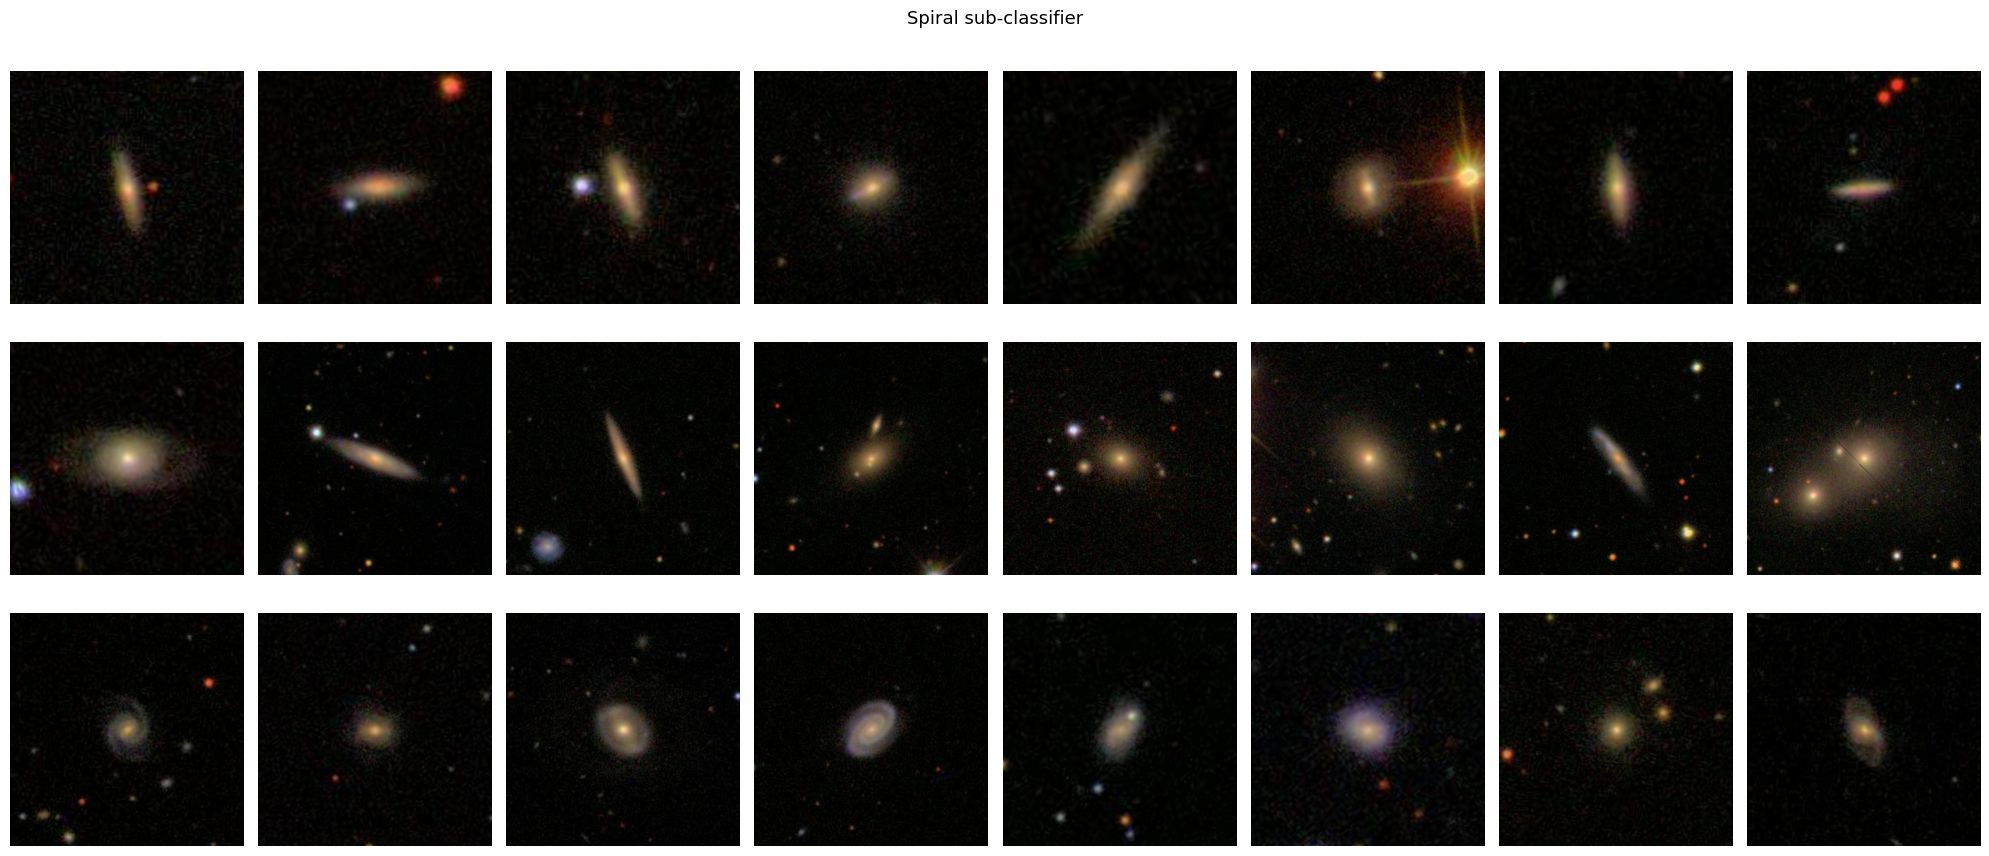

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

categories = {
    'Barred Spiral':   '../data/gz2/spiral_barred',
    'Unbarred Spiral': '../data/gz2/spiral_unbarred',
    'Grand Design':    '../data/gz2/spiral_grand_design',
}

fig, axes = plt.subplots(3, 8, figsize=(20, 9))

for row, (cat_name, folder) in enumerate(categories.items()):
    files = os.listdir(folder)[:8]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname)).convert('RGB')
        axes[row, col].imshow(np.array(img))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(cat_name, fontsize=9)

plt.suptitle('Spiral sub-classifier', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
#Nebulaa

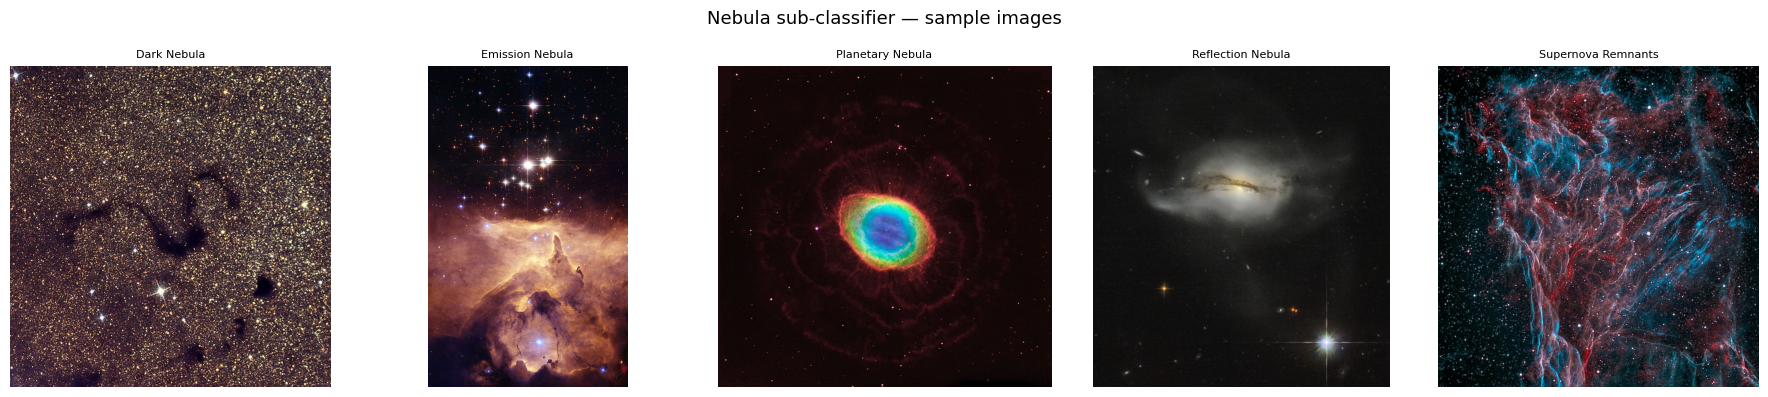

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

base = '../data/nebula/Nebulae'
classes = ['Dark Nebula', 'Emission Nebula', 'Planetary Nebula', 'Reflection Nebula', 'Supernova Remnants']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, cls in zip(axes, classes):
    folder = os.path.join(base, cls)
    fname = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, fname)).convert('RGB')
    ax.imshow(np.array(img))
    ax.set_title(cls, fontsize=8)
    ax.axis('off')

plt.suptitle('Nebula sub-classifier', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from PIL import Image
from src.models.trainer import train, final_evaluate

NEBULA_CLASSES = [
    'Dark Nebula',
    'Emission Nebula',
    'Planetary Nebula',
    'Reflection Nebula',
    'Supernova Remnants',
]


NEBULA_FOLDER_MAP = {
    'Dark Nebula':        0,
    'Emission Nebula':    1,
    'Planetary Nebula':   2,
    'Reflection Nebula':  3,
    'Supernova Remnants': 4,
}

BASE_DIR    = '../data/nebula/Nebulae'
VAL_DIR     = '../data/nebula/Nebulae/Validation'
TARGET_COUNT = 300
BATCH_SIZE   = 32
DEVICE       = torch.device('mps')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms(split='train'):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(180),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
])


class NebulaDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


def load_folder(folder_path):
    images = []
    for fname in os.listdir(folder_path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        try:
            img = Image.open(os.path.join(folder_path, fname)).convert('RGB')
            images.append(np.array(img, dtype=np.uint8))
        except:
            pass
    return images

all_images, all_labels = [], []

for folder_name, class_idx in NEBULA_FOLDER_MAP.items():
    main_path = os.path.join(BASE_DIR, folder_name)
    originals = load_folder(main_path)


    val_folder_map = {
        'Dark Nebula':        'Dark Nebula',
        'Emission Nebula':    'Emission Nebula',
        'Planetary Nebula':   'Planetary Nebula',
        'Reflection Nebula':  'Reflection Nebula',
        'Supernova Remnants': 'Supernova Remnant',  # note singular
    }
    val_path = os.path.join(VAL_DIR, val_folder_map[folder_name])
    if os.path.isdir(val_path):
        originals += load_folder(val_path)

    n_orig = len(originals)

    for img in originals:
        all_images.append(img)
        all_labels.append(class_idx)

    needed = TARGET_COUNT - n_orig
    if needed > 0:
        for i in range(needed):
            src = Image.fromarray(originals[i % n_orig])
            aug = aug_transform(src)
            aug_np = (aug.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
            all_images.append(aug_np)
            all_labels.append(class_idx)

    print(f"{folder_name}: {n_orig} original → {max(n_orig, TARGET_COUNT)} total")

all_labels = np.array(all_labels)
print(f"\nTotal: {len(all_images)} images, {len(NEBULA_CLASSES)} classes")

indices = np.arange(len(all_images))
idx_train, idx_temp = train_test_split(indices, test_size=0.30, random_state=42, stratify=all_labels)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50, random_state=42, stratify=all_labels[idx_temp])

def subset(idx_list):
    return [all_images[i] for i in idx_list], all_labels[idx_list]

X_train, y_train = subset(idx_train)
X_val,   y_val   = subset(idx_val)
X_test,  y_test  = subset(idx_test)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

train_dataset = NebulaDataset(X_train, y_train, get_transforms('train'))
val_dataset   = NebulaDataset(X_val,   y_val,   get_transforms('val'))
test_dataset  = NebulaDataset(X_test,  y_test,  get_transforms('test'))

counts  = np.bincount(y_train)
weights = torch.tensor(1.0 / counts[y_train], dtype=torch.float)
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)


def build_nebula_model(num_classes=5, freeze_backbone=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )
    return model

print("\n=== Phase 1: training classifier head ===")
model = build_nebula_model(num_classes=5, freeze_backbone=True).to(DEVICE)

config_p1 = {
    'epochs': 10, 'lr': 1e-3, 'weight_decay': 1e-4,
    'checkpoint_dir': '../outputs/checkpoints/',
    'run_name': 'nebula_phase1', 'use_wandb': False,
}
train(model, train_loader, val_loader, config_p1, DEVICE, NEBULA_CLASSES)

print("\n=== Phase 2: fine-tuning full network ===")
model = build_nebula_model(num_classes=5, freeze_backbone=False).to(DEVICE)
model.load_state_dict(torch.load('../outputs/checkpoints/nebula_phase1_best.pth', map_location=DEVICE))

config_p2 = {
    'epochs': 15, 'lr': 1e-4, 'weight_decay': 1e-4,
    'checkpoint_dir': '../outputs/checkpoints/',
    'run_name': 'nebula_phase2', 'use_wandb': False,
}
train(model, train_loader, val_loader, config_p2, DEVICE, NEBULA_CLASSES)

print("\n=== Final evaluation ===")
model.load_state_dict(torch.load('../outputs/checkpoints/nebula_phase2_best.pth', map_location=DEVICE))
cm = final_evaluate(model, test_loader, DEVICE, NEBULA_CLASSES)
print(cm)

Dark Nebula: 81 original → 300 total
Emission Nebula: 801 original → 801 total
Planetary Nebula: 336 original → 336 total
Reflection Nebula: 63 original → 300 total
Supernova Remnants: 103 original → 300 total

Total: 2037 images, 5 classes
Train: 1425 | Val: 306 | Test: 306

=== Phase 1: training classifier head ===
Epoch 01/10 | Train loss: 1.2148 acc: 0.5214 | Val loss: 0.9903 acc: 0.6438
  ✓ New best model saved (0.6438)
Epoch 02/10 | Train loss: 0.9185 acc: 0.6688 | Val loss: 0.8231 acc: 0.7222
  ✓ New best model saved (0.7222)
Epoch 03/10 | Train loss: 0.8135 acc: 0.6933 | Val loss: 0.7807 acc: 0.7451
  ✓ New best model saved (0.7451)
Epoch 04/10 | Train loss: 0.8203 acc: 0.6954 | Val loss: 0.7640 acc: 0.7516
  ✓ New best model saved (0.7516)
Epoch 05/10 | Train loss: 0.7282 acc: 0.7207 | Val loss: 0.7417 acc: 0.7451
Epoch 06/10 | Train loss: 0.7458 acc: 0.7186 | Val loss: 0.7683 acc: 0.7190
Epoch 07/10 | Train loss: 0.7414 acc: 0.7228 | Val loss: 0.7330 acc: 0.7320
Epoch 08/10 |

In [ ]:
#All three categories seem nearly identical in terms of visual features, making it a very challenging classification task. So I am keeping the subclassifier only for planetary system and nebula.